In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('loan.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [11]:
df_new=df.drop('loan_id',axis=1)
print(df_new.head())

   no_of_dependents      education self_employed  income_annum  loan_amount  \
0                 2       Graduate            No       9600000     29900000   
1                 0   Not Graduate           Yes       4100000     12200000   
2                 3       Graduate            No       9100000     29700000   
3                 3       Graduate            No       8200000     30700000   
4                 5   Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value loa

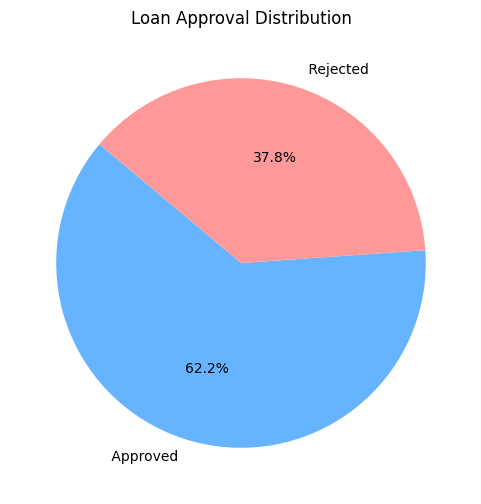

In [14]:
df.columns = df.columns.str.strip()
plt.figure(figsize=(6, 6))
# Count the values in 'loan_status'
status_counts = df['loan_status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Loan Approval Distribution')
plt.show()

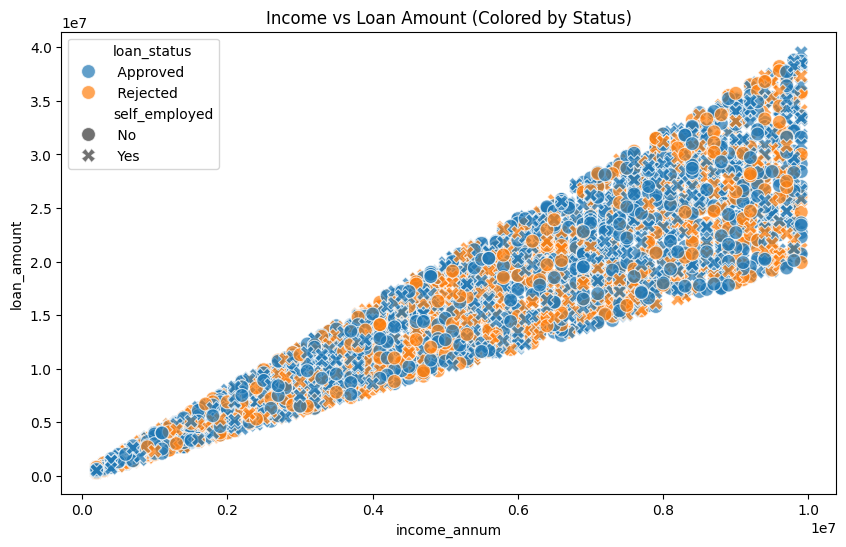

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='income_annum', 
    y='loan_amount', 
    hue='loan_status',  # Colors points by Approved/Rejected
    style='self_employed', # Different shapes for Self Employed or not
    s=100,
    alpha=0.7
)
plt.title('Income vs Loan Amount (Colored by Status)')
plt.show()

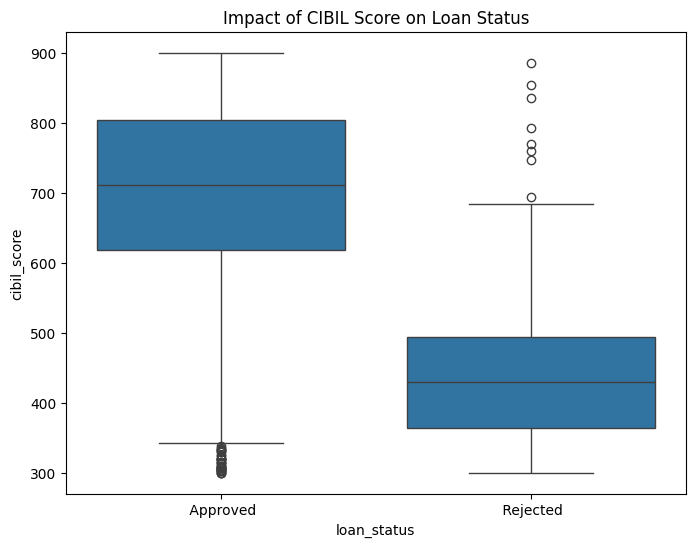

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='loan_status', y='cibil_score')
plt.title('Impact of CIBIL Score on Loan Status')
plt.show()

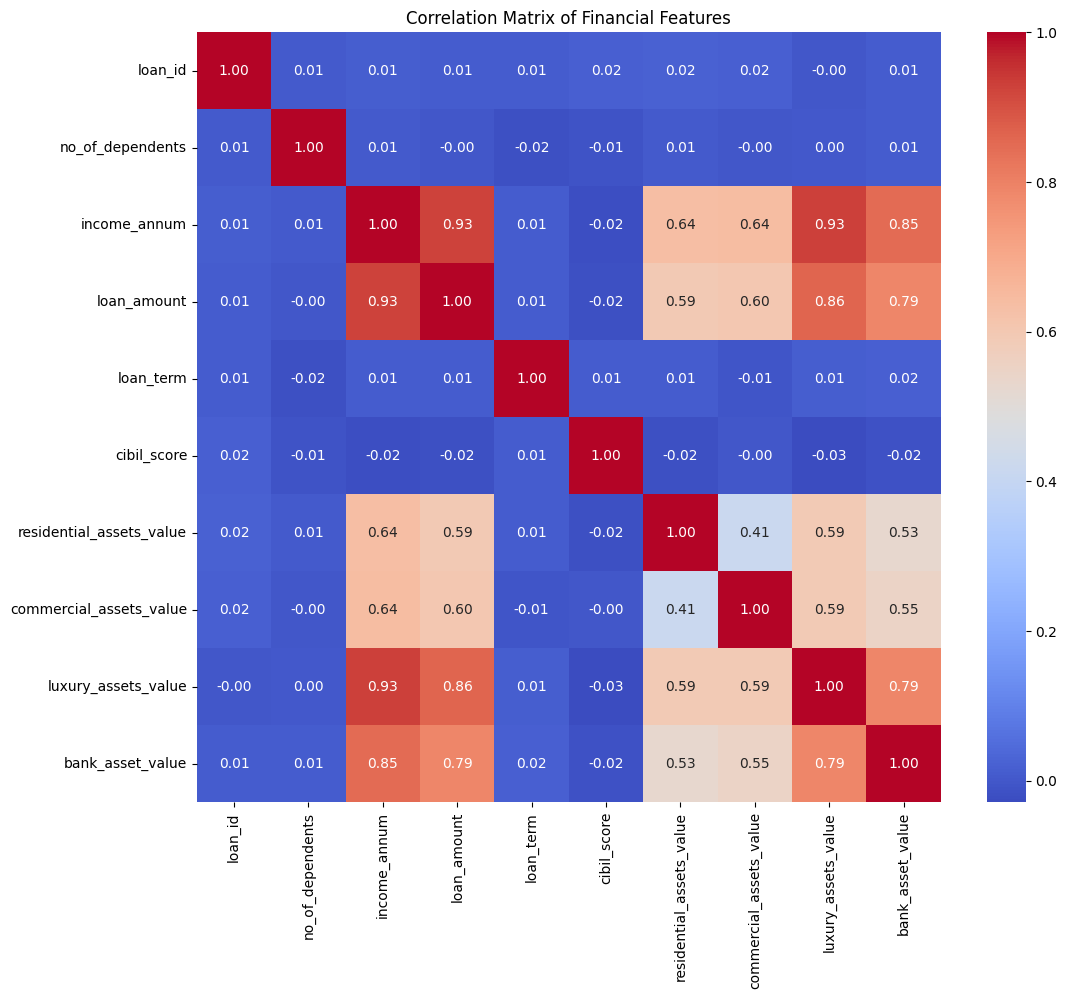

In [29]:
plt.figure(figsize=(12, 10))

# We drop non-numeric columns for the correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Financial Features')
plt.show()

<Figure size 1000x800 with 0 Axes>

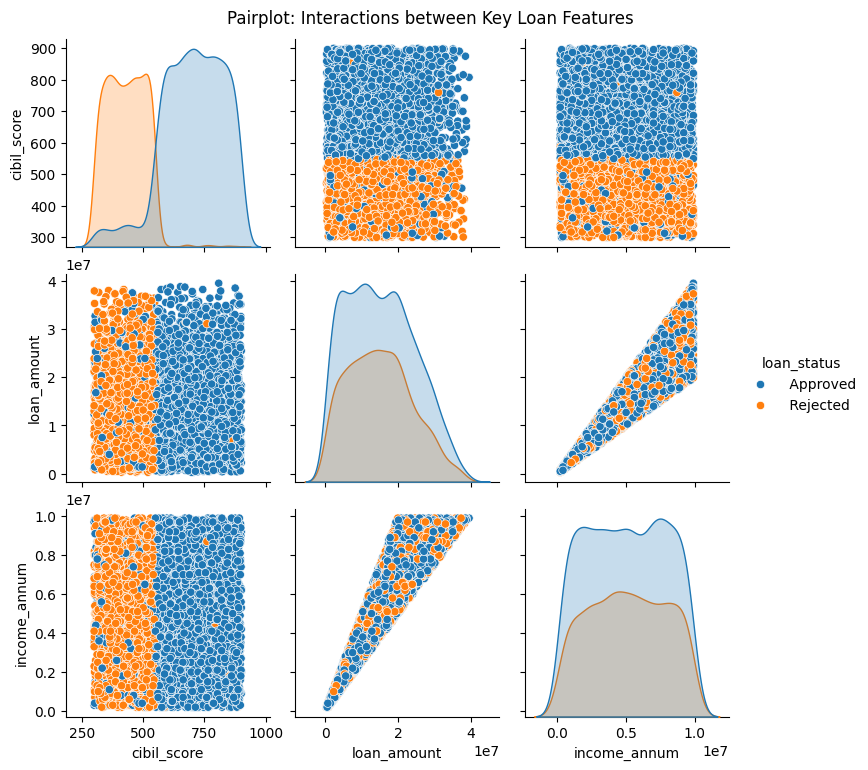

In [35]:
cols_to_plot = ['cibil_score', 'loan_amount', 'income_annum', 'loan_status']
plt.figure(figsize=(10,8))
sns.pairplot(df[cols_to_plot],hue='loan_status',diag_kind='kde')
plt.suptitle('Pairplot: Interactions between Key Loan Features', y=1.02)
plt.show()